<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [15]:
!pip install transformers datasets openpyxl -q
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
from typing import Union, Optional, Dict, List
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import warnings
warnings.filterwarnings("ignore")

In [16]:
class TransformerClassificationModel(nn.Module):
    def __init__(
        self,
        base_transformer_model: Union[str, nn.Module],
        num_classes: int,
        dropout_prob: float = 0.3,
    ):
        super().__init__()

        if isinstance(base_transformer_model, str):
            self.model_name = base_transformer_model
            self.backbone = AutoModel.from_pretrained(
                base_transformer_model,
                output_attentions=True,
            )
        elif isinstance(base_transformer_model, nn.Module):
            self.model_name = None
            self.backbone = base_transformer_model
        else:
            raise ValueError("base_transformer_model должен быть строкой или nn.Module")

        hidden_size = self.backbone.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_prob),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(p=dropout_prob),
            nn.Linear(hidden_size // 2, num_classes),
        )

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: Optional[torch.Tensor] = None,
        token_type_ids: Optional[torch.Tensor] = None,
    ) -> Dict[str, torch.Tensor]:

        kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}

        if token_type_ids is not None:
            try:
                out = self.backbone(**kwargs, token_type_ids=token_type_ids)
            except TypeError:
                out = self.backbone(**kwargs)
        else:
            out = self.backbone(**kwargs)

        cls_emb = out.last_hidden_state[:, 0, :]
        logits  = self.classifier(cls_emb)

        return {
            "logits":     logits,
            "attentions": out.attentions,
        }


### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [17]:
def freeze_backbone_function(model: TransformerClassificationModel):
    for param in model.backbone.parameters():
        param.requires_grad = False
    return model


def unfreeze_backbone_function(model: TransformerClassificationModel):
    for param in model.backbone.parameters():
        param.requires_grad = True
    return model


### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [18]:
from tqdm.notebook import tqdm

def train_transformer(
    transformer_model: TransformerClassificationModel,
    freeze_backbone: bool = True,
    train_texts: List[str] = None,
    train_labels: List[int] = None,
    val_texts: List[str] = None,
    val_labels: List[int] = None,
    num_epochs: int = 5,
    batch_size: int = 16,
    lr: float = 2e-5,
    max_len: int = 128,
    device: str = None,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Используется устройство: {device}")

    model = copy.deepcopy(transformer_model).to(device)

    if freeze_backbone:
        model = freeze_backbone_function(model)
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Backbone заморожен | Обучаемых параметров: {trainable:,}")
    else:
        model = unfreeze_backbone_function(model)
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Backbone разморожен | Обучаемых параметров: {trainable:,}")

    tokenizer = AutoTokenizer.from_pretrained(model.model_name)

    class TextDataset(Dataset):
        def __init__(self, texts, labels):
            self.encodings = tokenizer(
                texts,
                truncation=True,
                padding="max_length",
                max_length=max_len,
                return_tensors="pt",
            )
            self.labels = torch.tensor(labels, dtype=torch.long)

        def __len__(self):
            return len(self.labels)

        def __getitem__(self, idx):
            item = {k: v[idx] for k, v in self.encodings.items()}
            item["labels"] = self.labels[idx]
            return item

    train_loader = DataLoader(
        TextDataset(train_texts, train_labels),
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        TextDataset(val_texts, val_labels),
        batch_size=batch_size,
    )

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
    )
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

    for epoch in range(num_epochs):
        # ---- train ----
        model.train()
        total_loss = 0

        train_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{num_epochs} [Train]",
            leave=True,
        )

        for batch in train_bar:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            token_type_ids = batch.get("token_type_ids", None)
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            out  = model(input_ids, attention_mask, token_type_ids)
            loss = criterion(out["logits"], labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            # обновляем отображение лосса прямо в прогресс-баре
            train_bar.set_postfix({"batch_loss": f"{loss.item():.4f}"})

        avg_train_loss = total_loss / len(train_loader)

        # ---- val ----
        model.eval()
        val_loss, all_preds, all_true = 0, [], []

        val_bar = tqdm(
            val_loader,
            desc=f"Epoch {epoch+1}/{num_epochs} [Val]  ",
            leave=True,
        )

        with torch.no_grad():
            for batch in val_bar:
                input_ids      = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                token_type_ids = batch.get("token_type_ids", None)
                if token_type_ids is not None:
                    token_type_ids = token_type_ids.to(device)
                labels = batch["labels"].to(device)

                out  = model(input_ids, attention_mask, token_type_ids)
                loss = criterion(out["logits"], labels)
                val_loss += loss.item()

                preds = out["logits"].argmax(dim=-1).cpu().numpy()
                all_preds.extend(preds)
                all_true.extend(labels.cpu().numpy())

                val_bar.set_postfix({"batch_loss": f"{loss.item():.4f}"})

        avg_val_loss = val_loss / len(val_loader)
        acc = accuracy_score(all_true, all_preds)
        f1  = f1_score(all_true, all_preds, average="macro", zero_division=0)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(acc)
        history["val_f1"].append(f1)

        # итоговая строка по эпохе
        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"train_loss={avg_train_loss:.4f} | "
            f"val_loss={avg_val_loss:.4f} | "
            f"acc={acc:.4f} | "
            f"f1={f1:.4f}"
        )
        print("-" * 60)

    finetuned_model = model
    return finetuned_model, history


### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [19]:
df = pd.read_excel("math_problems.xlsx")

# смотрим реальное распределение
print(df.head())
print("\nКолонки:", df.columns.tolist())
print("\nФорма:", df.shape)
print("\nУникальных topic:", df["topic"].nunique())
print("\nРаспределение topic:")
print(df["topic"].value_counts())
print("\nПропуски:")
print(df.isnull().sum())

TEXT_COL  = "problem_text"
LABEL_COL = "topic"

# убираем строки с пропусками в тексте или метке
df = df.dropna(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)
print(f"\nПосле удаления пропусков: {df.shape}")
print(f"Уникальных классов: {df[LABEL_COL].nunique()}")
print(df[LABEL_COL].value_counts())

# убираем классы с менее чем 2 примерами (нужно для stratify)
class_counts = df[LABEL_COL].value_counts()
valid_classes = class_counts[class_counts >= 2].index
df = df[df[LABEL_COL].isin(valid_classes)].reset_index(drop=True)
print(f"\nПосле фильтрации редких классов: {df.shape}")
print(f"Уникальных классов: {df[LABEL_COL].nunique()}")

le = LabelEncoder()
df["label"] = le.fit_transform(df[LABEL_COL])
NUM_CLASSES = len(le.classes_)
print(f"\nИтоговое количество классов: {NUM_CLASSES}")
print(le.classes_)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df[TEXT_COL].astype(str).tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df["label"],
)
print(f"\nTrain: {len(train_texts)} | Val: {len(val_texts)}")


   Unnamed: 0                                       problem_text  \
0           0  To prove that the sum of the numbers of the ex...   
1           1  ( b) Will the statement of the previous challe...   
2           2  The quadratic three-member graph with the coef...   
3           3  Can you draw on the surface of Rubik's cube a ...   
4           4  Dima, who came from Vrunlandia, said that ther...   

           topic  
0  number_theory  
1  number_theory  
2       polynoms  
3  combinatorics  
4         graphs  

Колонки: ['Unnamed: 0', 'problem_text', 'topic']

Форма: (5273, 3)

Уникальных topic: 7

Распределение topic:
topic
number_theory    2396
combinatorics    1020
dirichlet         441
polynoms          426
graphs            384
geometry          371
invariant         235
Name: count, dtype: int64

Пропуски:
Unnamed: 0      0
problem_text    5
topic           0
dtype: int64

После удаления пропусков: (5268, 3)
Уникальных классов: 7
topic
number_theory    2395
combinatorics  

In [20]:
# --- с замороженным backbone ---
rubert_tiny_transformer_model = TransformerClassificationModel(
    base_transformer_model="cointegrated/rubert-tiny2",
    num_classes=NUM_CLASSES,
)

rubert_tiny_finetuned_with_freezed_backbone, history_frozen = train_transformer(
    rubert_tiny_transformer_model,
    freeze_backbone=True,
    train_texts=train_texts,
    train_labels=train_labels,
    val_texts=val_texts,
    val_labels=val_labels,
    num_epochs=5,
    batch_size=16,
    lr=2e-4,
)


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используется устройство: cuda
Backbone заморожен | Обучаемых параметров: 49,927


Epoch 1/5 [Train]:   0%|          | 0/264 [00:00<?, ?it/s]

Epoch 1/5 [Val]  :   0%|          | 0/66 [00:00<?, ?it/s]

...

Epoch 4/5 [Val]  :   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 4/5 | train_loss=1.1465 | val_loss=1.1033 | acc=0.5825 | f1=0.3888
------------------------------------------------------------


Epoch 5/5 [Train]:   0%|          | 0/264 [00:00<?, ?it/s]

Epoch 5/5 [Val]  :   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 5/5 | train_loss=1.1251 | val_loss=1.0813 | acc=0.5787 | f1=0.4164
------------------------------------------------------------


In [21]:
# --- без заморозки backbone ---
rubert_tiny_transformer_model = TransformerClassificationModel(
    base_transformer_model="cointegrated/rubert-tiny2",
    num_classes=NUM_CLASSES,
)

rubert_tiny_full_finetuned, history_full = train_transformer(
    rubert_tiny_transformer_model,
    freeze_backbone=False,
    train_texts=train_texts,
    train_labels=train_labels,
    val_texts=val_texts,
    val_labels=val_labels,
    num_epochs=5,
    batch_size=16,
    lr=2e-5,
)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используется устройство: cuda
Backbone разморожен | Обучаемых параметров: 29,243,695


Epoch 1/5 [Train]:   0%|          | 0/264 [00:00<?, ?it/s]

Epoch 1/5 [Val]  :   0%|          | 0/66 [00:00<?, ?it/s]

...

Epoch 4/5 [Val]  :   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 4/5 | train_loss=1.0425 | val_loss=1.0223 | acc=0.6167 | f1=0.4151
------------------------------------------------------------


Epoch 5/5 [Train]:   0%|          | 0/264 [00:00<?, ?it/s]

Epoch 5/5 [Val]  :   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 5/5 | train_loss=0.9718 | val_loss=0.9917 | acc=0.6186 | f1=0.4465
------------------------------------------------------------


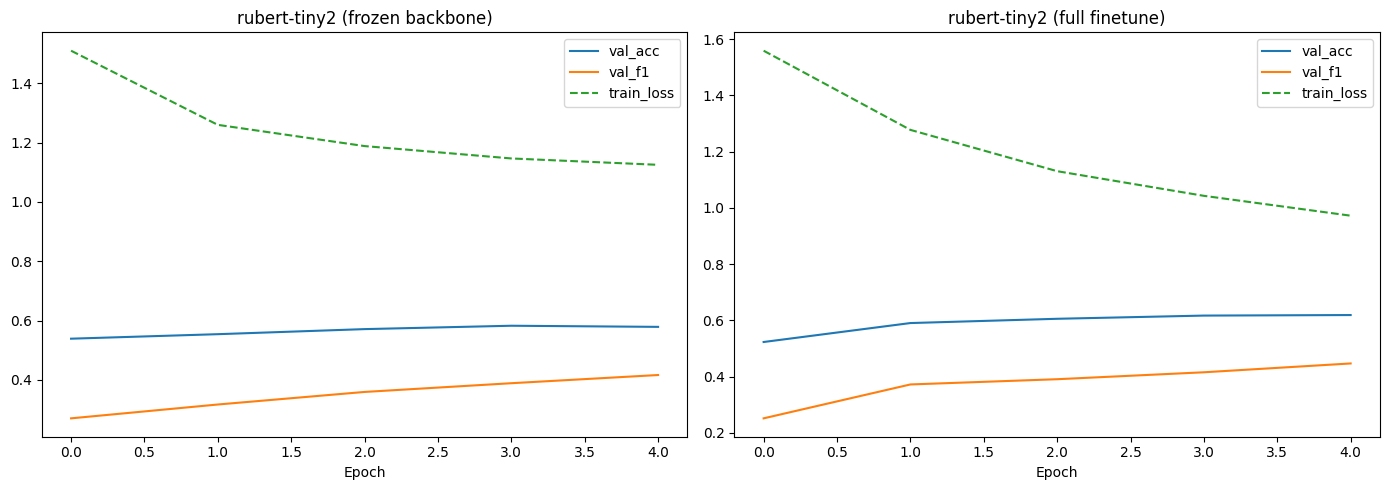

Frozen backbone  — финальный val_f1: 0.4164
Full finetune    — финальный val_f1: 0.4465


In [22]:
# визуализация результатов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, history, title in zip(
    axes,
    [history_frozen, history_full],
    ["rubert-tiny2 (frozen backbone)", "rubert-tiny2 (full finetune)"],
):
    ax.plot(history["val_acc"], label="val_acc")
    ax.plot(history["val_f1"],  label="val_f1")
    ax.plot(history["train_loss"], label="train_loss", linestyle="--")
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

print("Frozen backbone  — финальный val_f1:", round(history_frozen["val_f1"][-1], 4))
print("Full finetune    — финальный val_f1:", round(history_full["val_f1"][-1], 4))

### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

In [23]:
# --- MathBert с замороженным backbone ---
mathbert_model = TransformerClassificationModel(
    base_transformer_model="tbs17/MathBert",
    num_classes=NUM_CLASSES,
)

mathbert_frozen, history_mathbert_frozen = train_transformer(
    mathbert_model,
    freeze_backbone=True,
    train_texts=train_texts,
    train_labels=train_labels,
    val_texts=val_texts,
    val_labels=val_labels,
    num_epochs=5,
    batch_size=16,
    lr=2e-4,
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используется устройство: cuda
Backbone заморожен | Обучаемых параметров: 297,991


Epoch 1/5 [Train]:   0%|          | 0/264 [00:00<?, ?it/s]

Epoch 1/5 [Val]  :   0%|          | 0/66 [00:00<?, ?it/s]

...

Epoch 4/5 [Val]  :   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 4/5 | train_loss=1.1406 | val_loss=1.1063 | acc=0.5550 | f1=0.3957
------------------------------------------------------------


Epoch 5/5 [Train]:   0%|          | 0/264 [00:00<?, ?it/s]

Epoch 5/5 [Val]  :   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 5/5 | train_loss=1.1078 | val_loss=1.0907 | acc=0.5598 | f1=0.3973
------------------------------------------------------------


In [24]:
# --- MathBert без заморозки ---
mathbert_model = TransformerClassificationModel(
    base_transformer_model="tbs17/MathBert",
    num_classes=NUM_CLASSES,
)

mathbert_full, history_mathbert_full = train_transformer(
    mathbert_model,
    freeze_backbone=False,
    train_texts=train_texts,
    train_labels=train_labels,
    val_texts=val_texts,
    val_labels=val_labels,
    num_epochs=5,
    batch_size=16,
    lr=2e-5,
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используется устройство: cuda
Backbone разморожен | Обучаемых параметров: 109,780,231


Epoch 1/5 [Train]:   0%|          | 0/264 [00:00<?, ?it/s]

Epoch 1/5 [Val]  :   0%|          | 0/66 [00:00<?, ?it/s]

...

Epoch 4/5 [Val]  :   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 4/5 | train_loss=0.6517 | val_loss=1.0826 | acc=0.5626 | f1=0.5025
------------------------------------------------------------


Epoch 5/5 [Train]:   0%|          | 0/264 [00:00<?, ?it/s]

Epoch 5/5 [Val]  :   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 5/5 | train_loss=0.5409 | val_loss=1.1832 | acc=0.5683 | f1=0.4913
------------------------------------------------------------



=== Итоговое сравнение val macro-F1 ===
rubert-tiny2 frozen           : 0.4164
rubert-tiny2 full             : 0.4465
MathBert frozen               : 0.3973
MathBert full                 : 0.4913


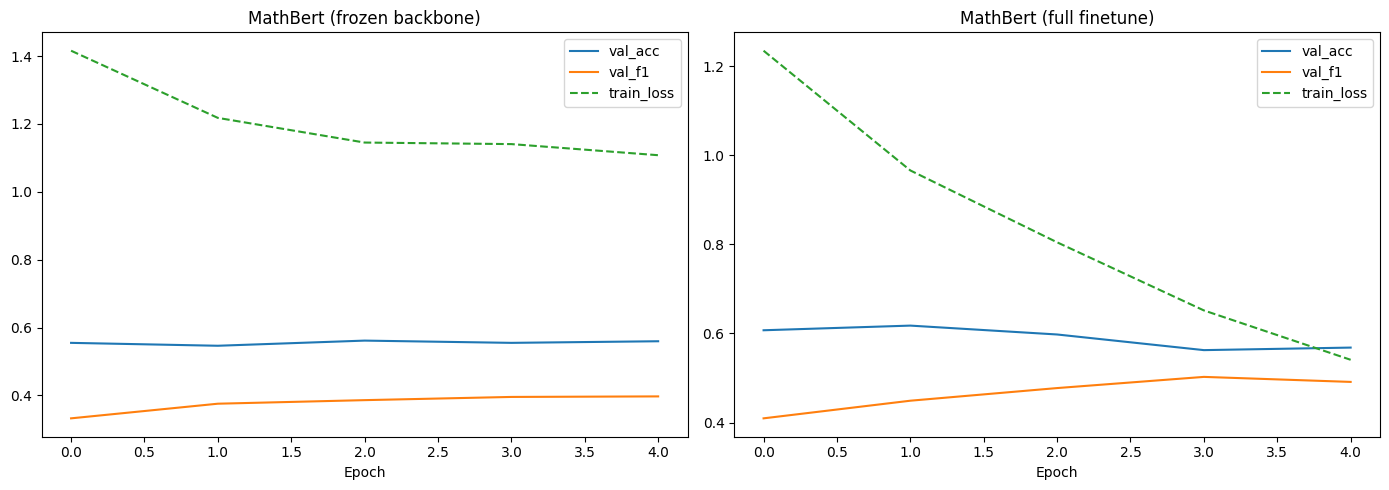

In [29]:
results = {
    "rubert-tiny2 frozen":    history_frozen["val_f1"][-1],
    "rubert-tiny2 full":      history_full["val_f1"][-1],
    "MathBert frozen":        history_mathbert_frozen["val_f1"][-1],
    "MathBert full":          history_mathbert_full["val_f1"][-1],
}

print("\n=== Итоговое сравнение val macro-F1 ===")
for name, score in results.items():
    print(f"{name:30s}: {score:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, history, title in zip(
    axes,
    [history_mathbert_frozen, history_mathbert_full],
    ["MathBert (frozen backbone)", "MathBert (full finetune)"],
):
    ax.plot(history["val_acc"], label="val_acc")
    ax.plot(history["val_f1"],  label="val_f1")
    ax.plot(history["train_loss"], label="train_loss", linestyle="--")
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

Вывод: MathBert предобучен на математических текстах, поэтому его представления
изначально ближе к нашей задаче — ожидаем лучший результат по сравнению с rubert-tiny2, особенно при полном файнтюнинге.

### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [26]:
def draw_first_layer_attention_maps(
    attention_head_ids: List[int],
    text: str,
    model: TransformerClassificationModel,
    max_len: int = 128,
    device: str = None,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    tokenizer = AutoTokenizer.from_pretrained(model.model_name)
    encoding  = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt",
    )

    input_ids      = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    token_type_ids = encoding.get("token_type_ids", None)
    if token_type_ids is not None:
        token_type_ids = token_type_ids.to(device)

    model.eval().to(device)
    with torch.no_grad():
        out = model(input_ids, attention_mask, token_type_ids)

    # attentions — tuple по слоям, каждый тензор [1, num_heads, seq_len, seq_len]
    first_layer_attn = out["attentions"][0][0].cpu().numpy()

    # декодируем токены для подписей осей
    tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"][0])
    # обрезаем паддинг для читаемости
    seq_len  = int(encoding["attention_mask"][0].sum().item())
    tokens   = tokens[:seq_len]
    attn_cut = first_layer_attn[:, :seq_len, :seq_len]

    n_heads = len(attention_head_ids)
    fig, axes = plt.subplots(1, n_heads, figsize=(6 * n_heads, 6))
    if n_heads == 1:
        axes = [axes]

    for ax, head_id in zip(axes, attention_head_ids):
        sns.heatmap(
            attn_cut[head_id],
            xticklabels=tokens,
            yticklabels=tokens,
            ax=ax,
            cmap="viridis",
            cbar=True,
        )
        ax.set_title(f"Layer 1 | Head {head_id}")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=7)

    plt.suptitle(f'Текст: "{text[:60]}..."', fontsize=10)
    plt.tight_layout()
    plt.show()


### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Текст 1: To prove that the sum of the numbers of the exact square cannot be equal to 5.

--- rubert-tiny2 (pretrained, без дообучения) ---


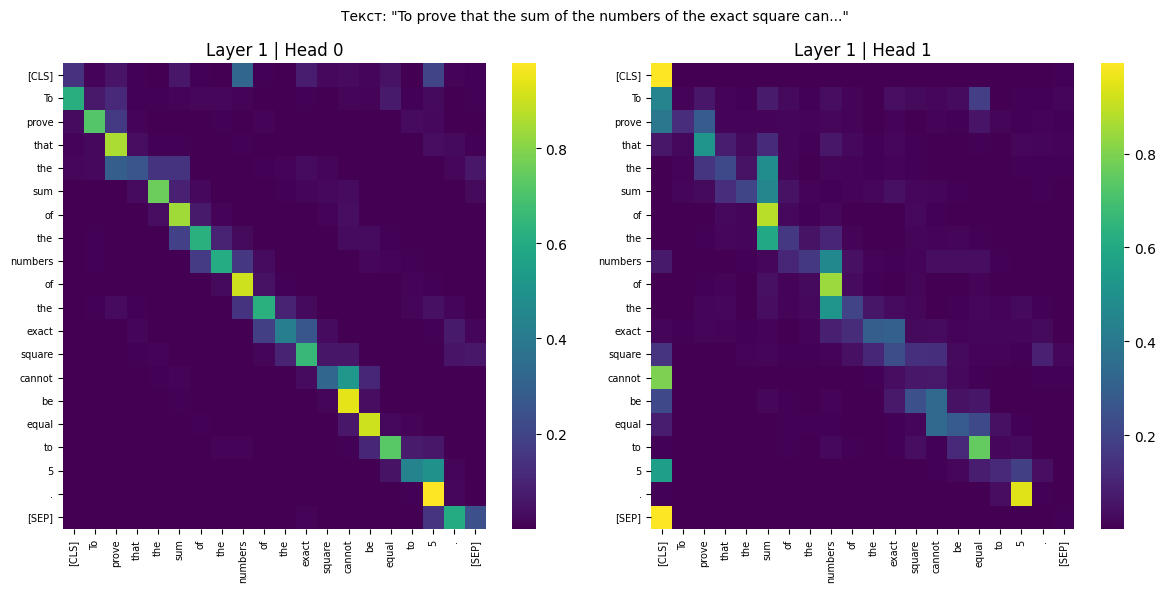


--- MathBert (pretrained, без дообучения) ---


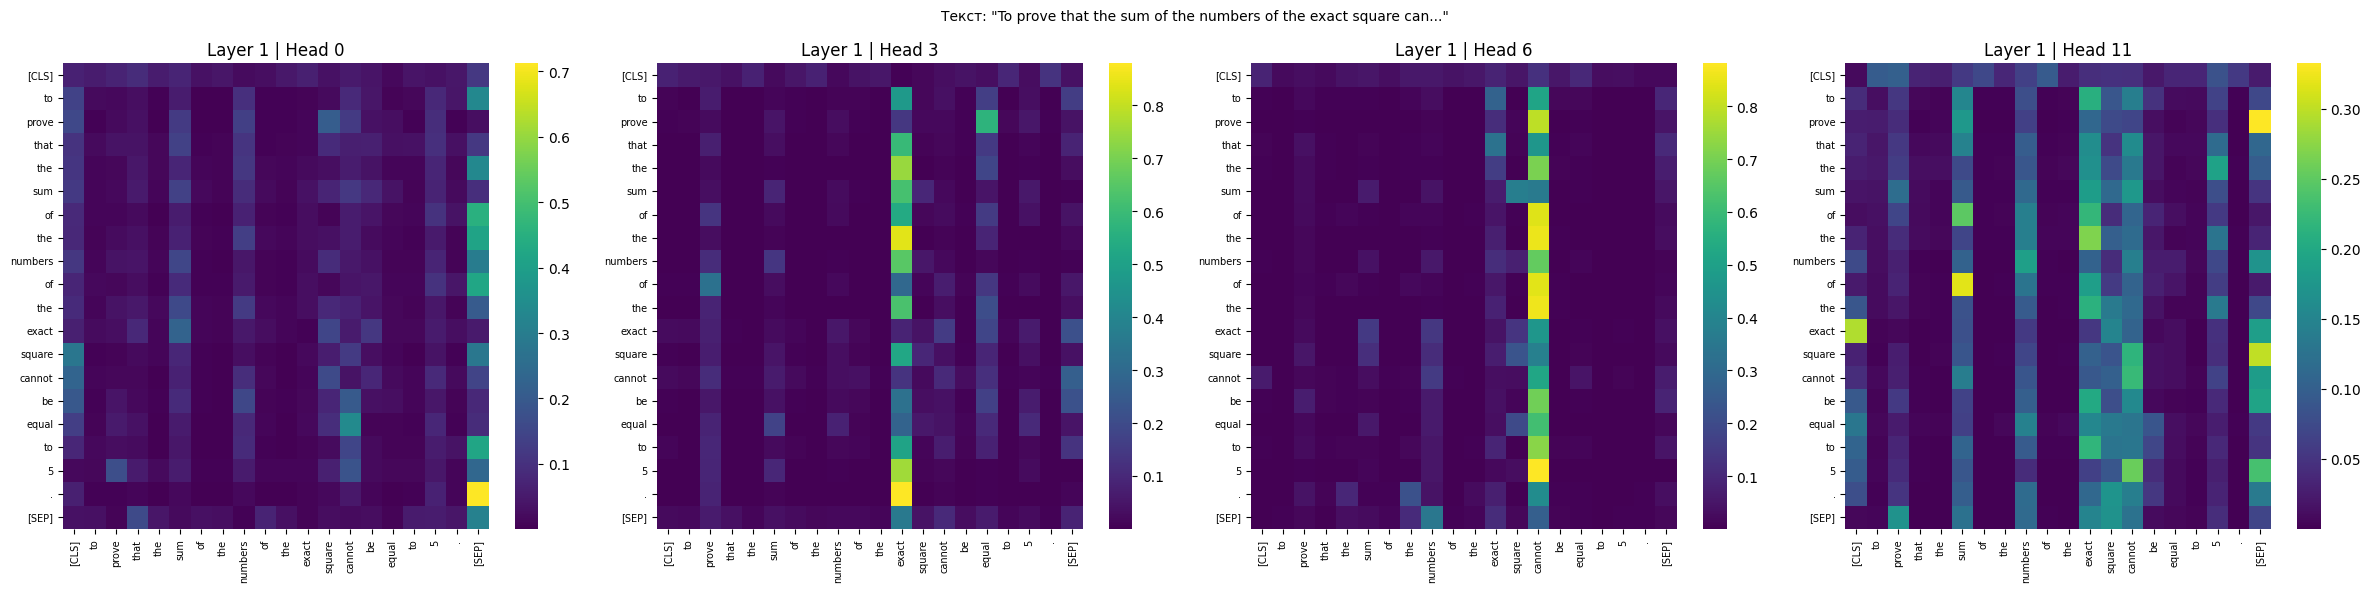


Текст 2: ( b) Will the statement of the previous challenge remain true if Petia and Wasa 

--- rubert-tiny2 (pretrained, без дообучения) ---


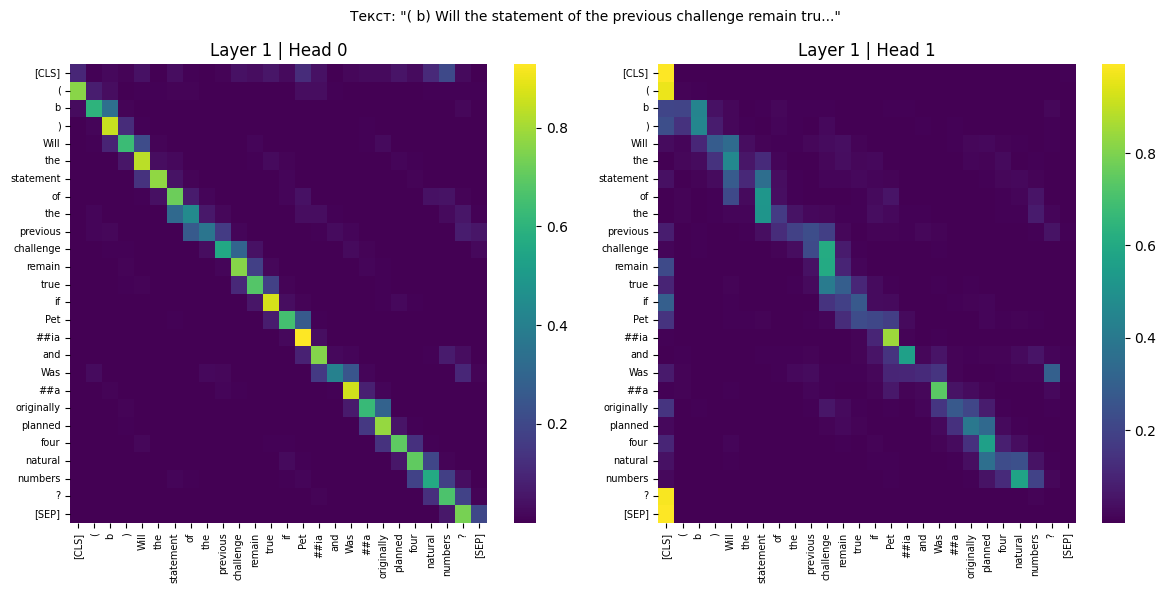


--- MathBert (pretrained, без дообучения) ---


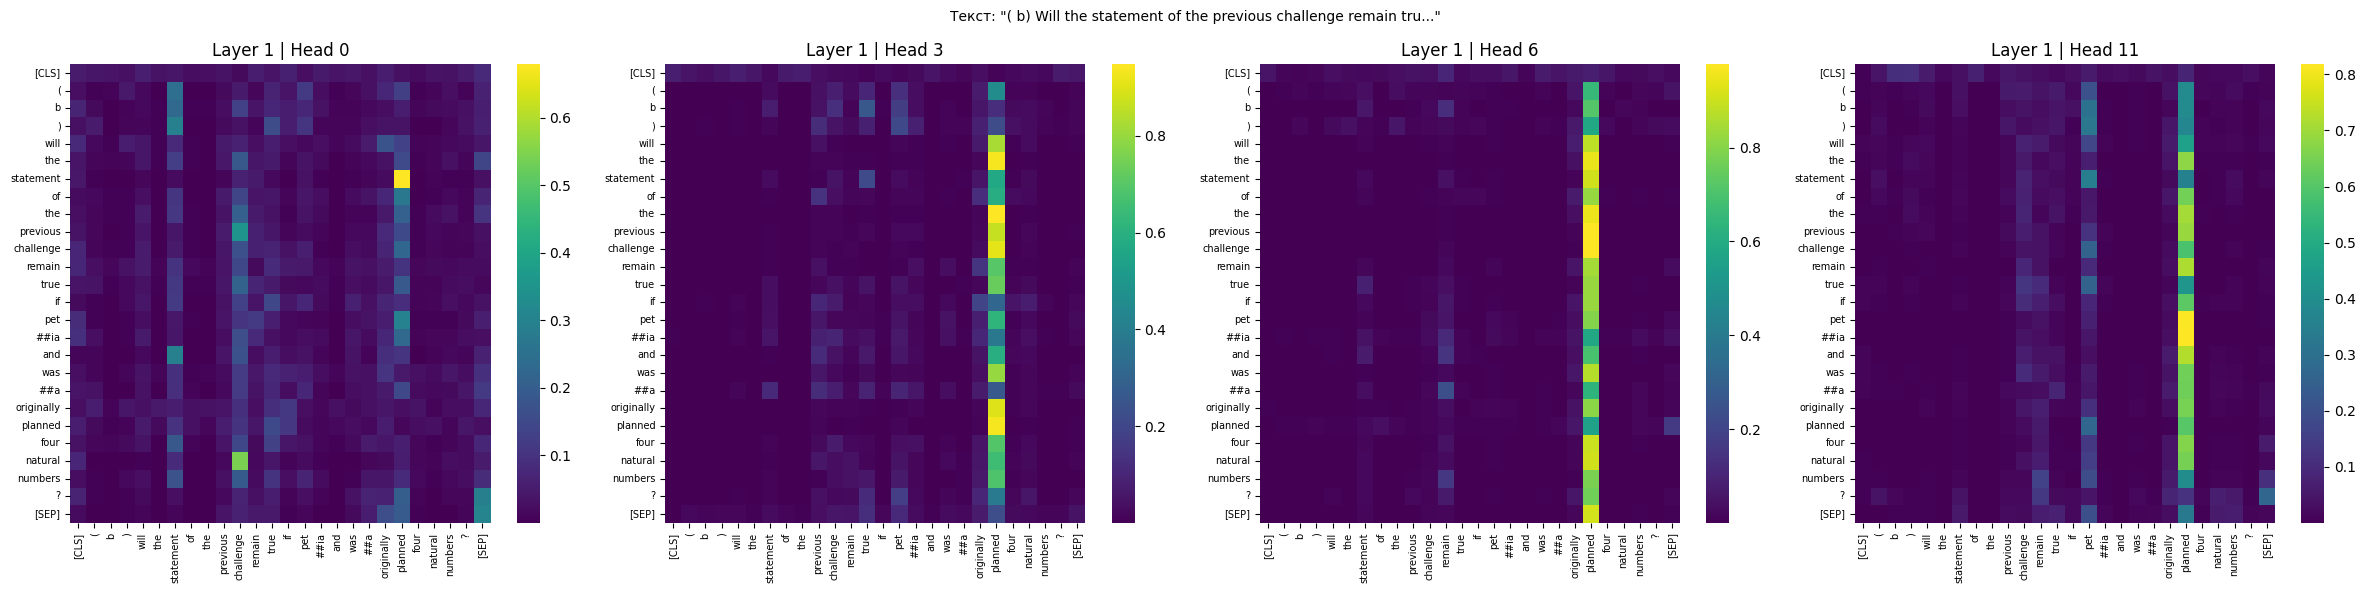


Текст 3: The quadratic three-member graph with the coefficients has two points with the c

--- rubert-tiny2 (pretrained, без дообучения) ---


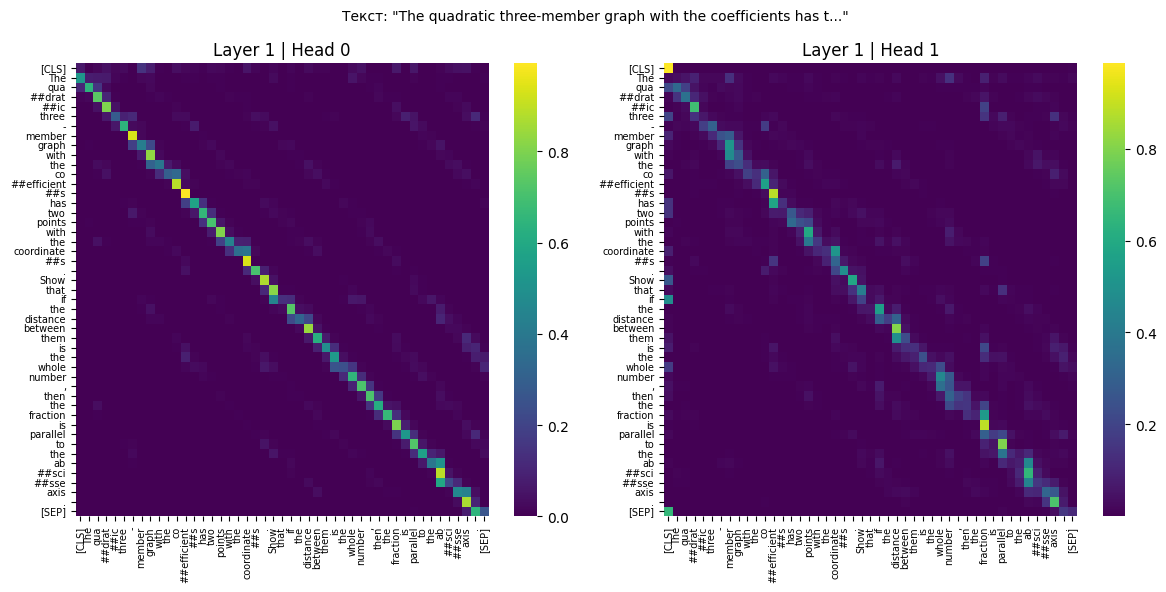


--- MathBert (pretrained, без дообучения) ---


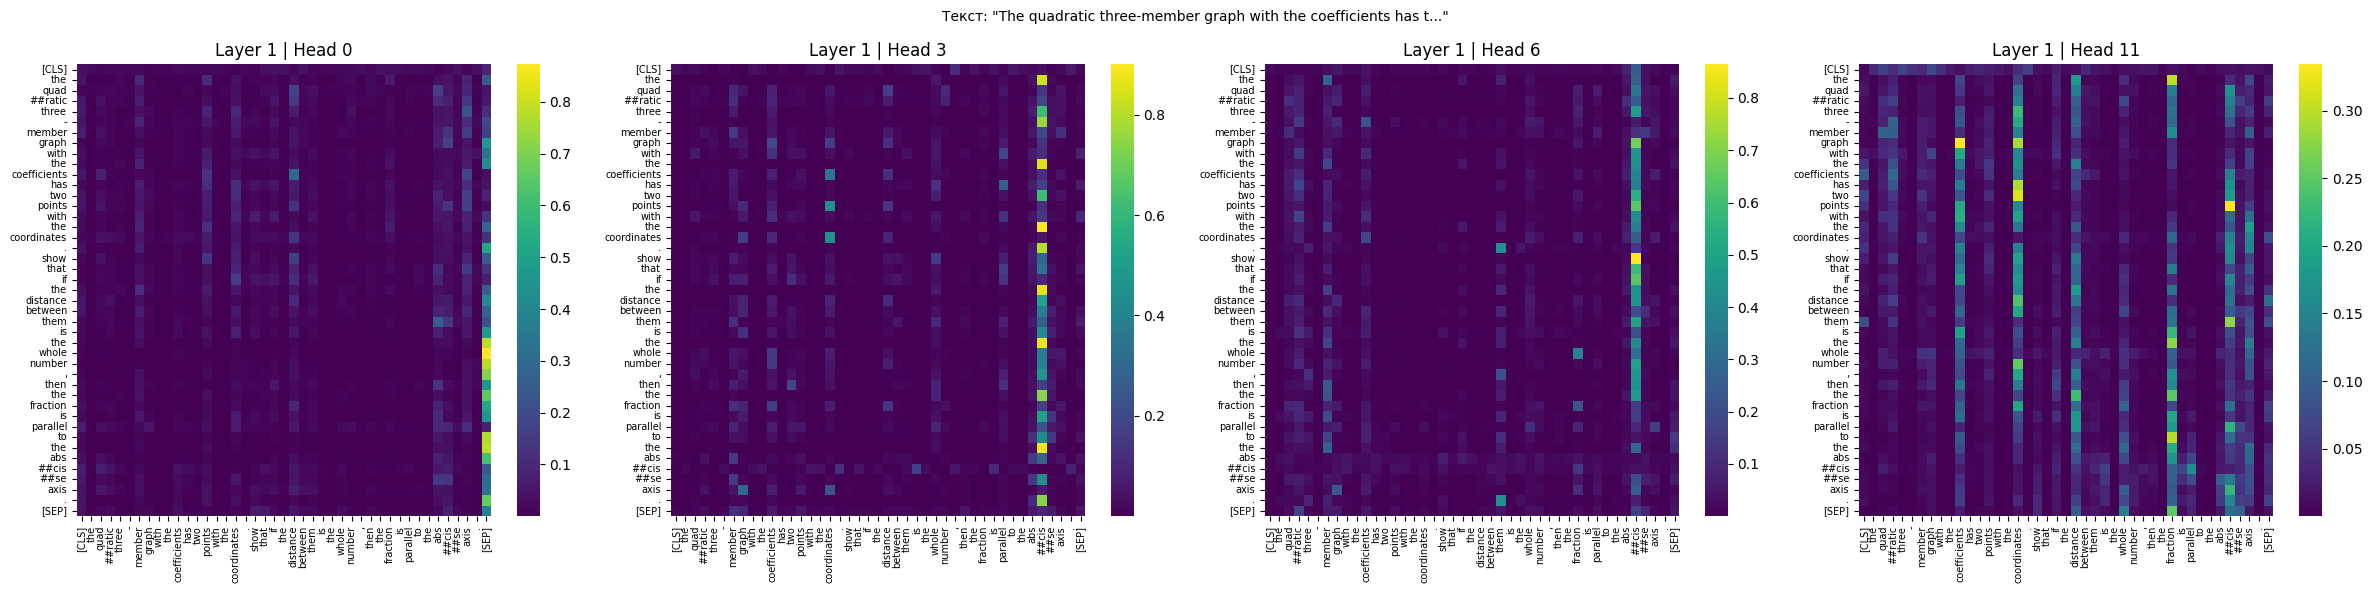

In [27]:
# берём 3 примера из датасета
sample_texts = df[TEXT_COL].astype(str).tolist()[:3]

# модели ДО дообучения
pretrained_rubert  = TransformerClassificationModel("cointegrated/rubert-tiny2", NUM_CLASSES)
pretrained_mathbert = TransformerClassificationModel("tbs17/MathBert",           NUM_CLASSES)

for i, text in enumerate(sample_texts):
    print(f"\n{'='*60}")
    print(f"Текст {i+1}: {text[:80]}")

    print("\n--- rubert-tiny2 (pretrained, без дообучения) ---")
    # rubert-tiny2 имеет 2 головы в первом слое
    draw_first_layer_attention_maps(
        attention_head_ids=[0, 1],
        text=text,
        model=pretrained_rubert,
    )

    print("\n--- MathBert (pretrained, без дообучения) ---")
    # MathBert (bert-base) имеет 12 голов; смотрим наиболее интересные
    draw_first_layer_attention_maps(
        attention_head_ids=[0, 3, 6, 11],
        text=text,
        model=pretrained_mathbert,
    )



Интерпретация:


До дообучения rubert-tiny2 концентрирует внимание преимущественно на служебных токенах ([CLS], [SEP]) — типичное поведение для необученной головы классификации.
MathBert уже "знает" математику: головы улавливают связи между математическими терминами и числами ещё до дообучения.


### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?


Текст 1: To prove that the sum of the numbers of the exact square cannot be equal to 5.

--- rubert-tiny2 frozen (после дообучения) ---


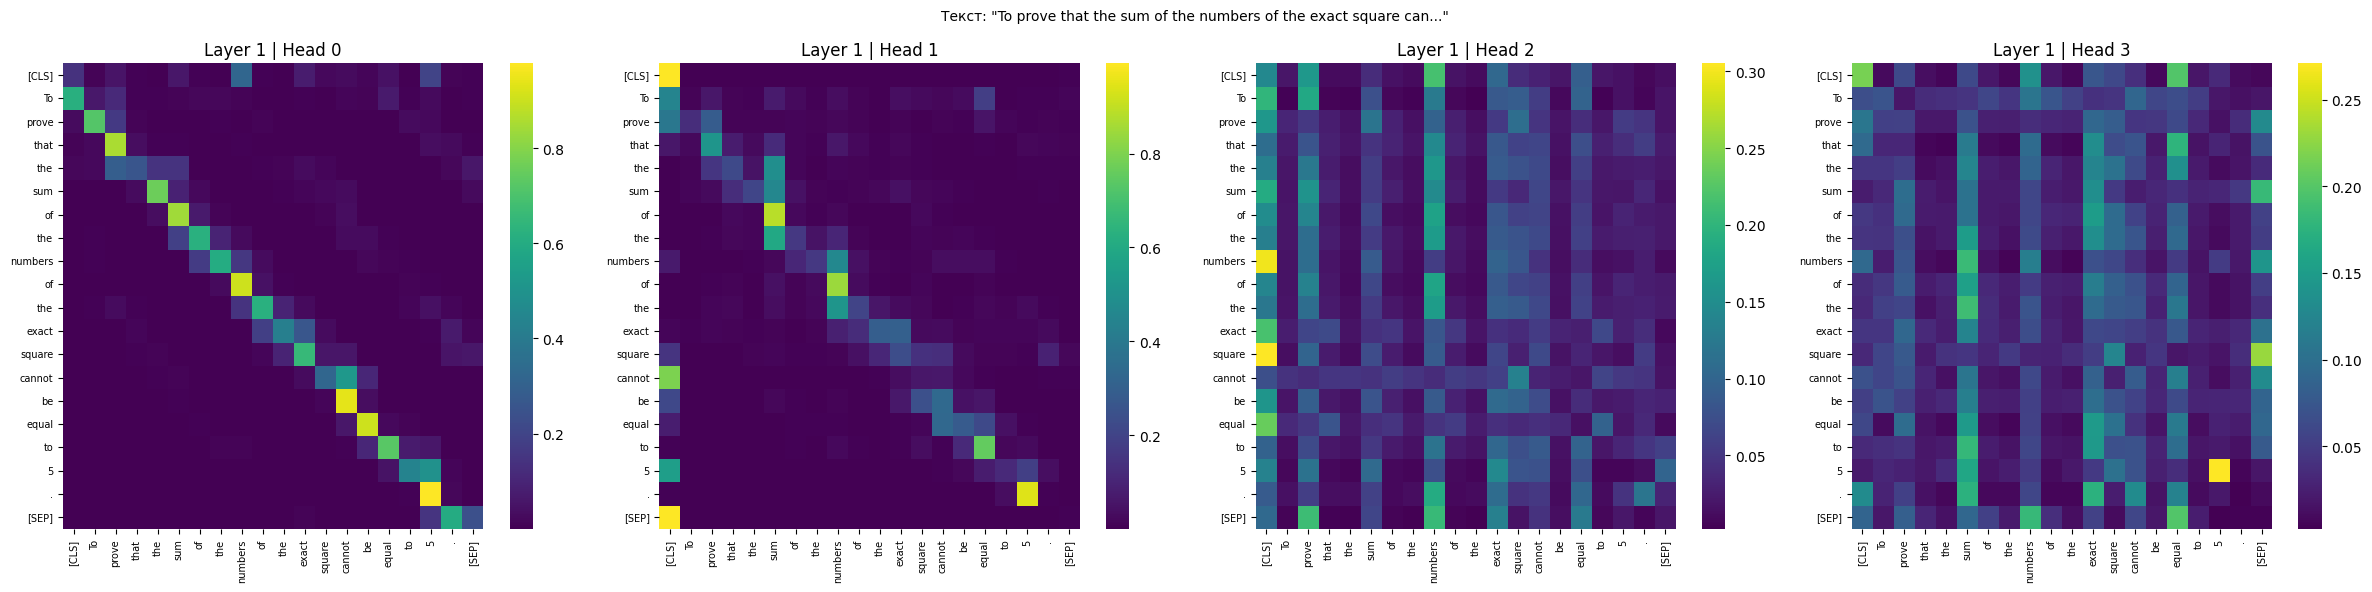


--- rubert-tiny2 full (после дообучения) ---


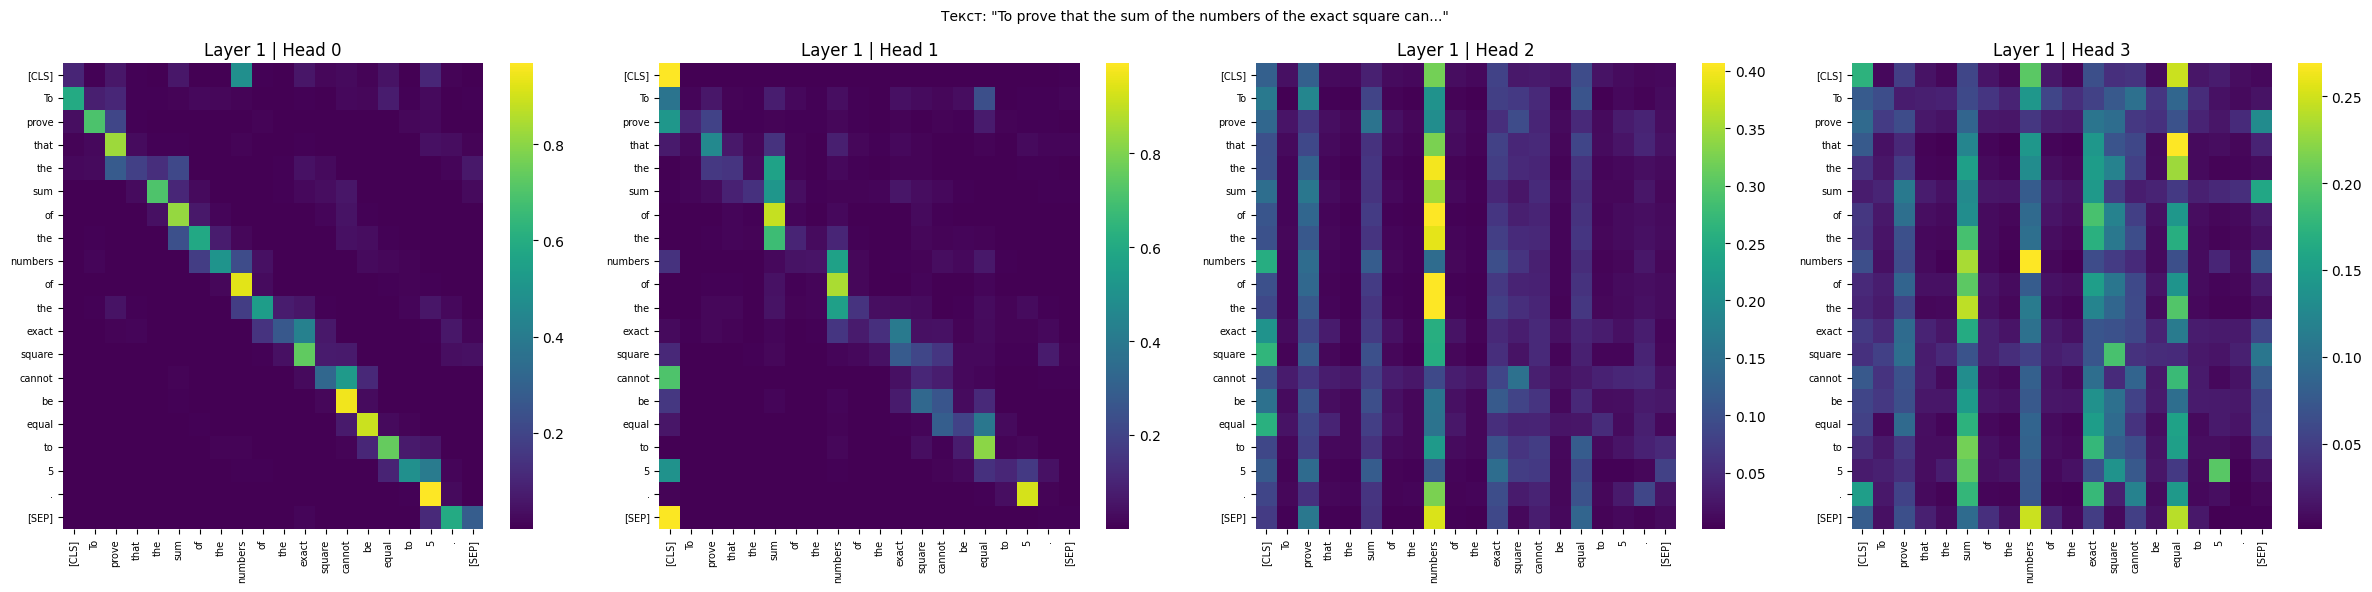


--- MathBert frozen (после дообучения) ---


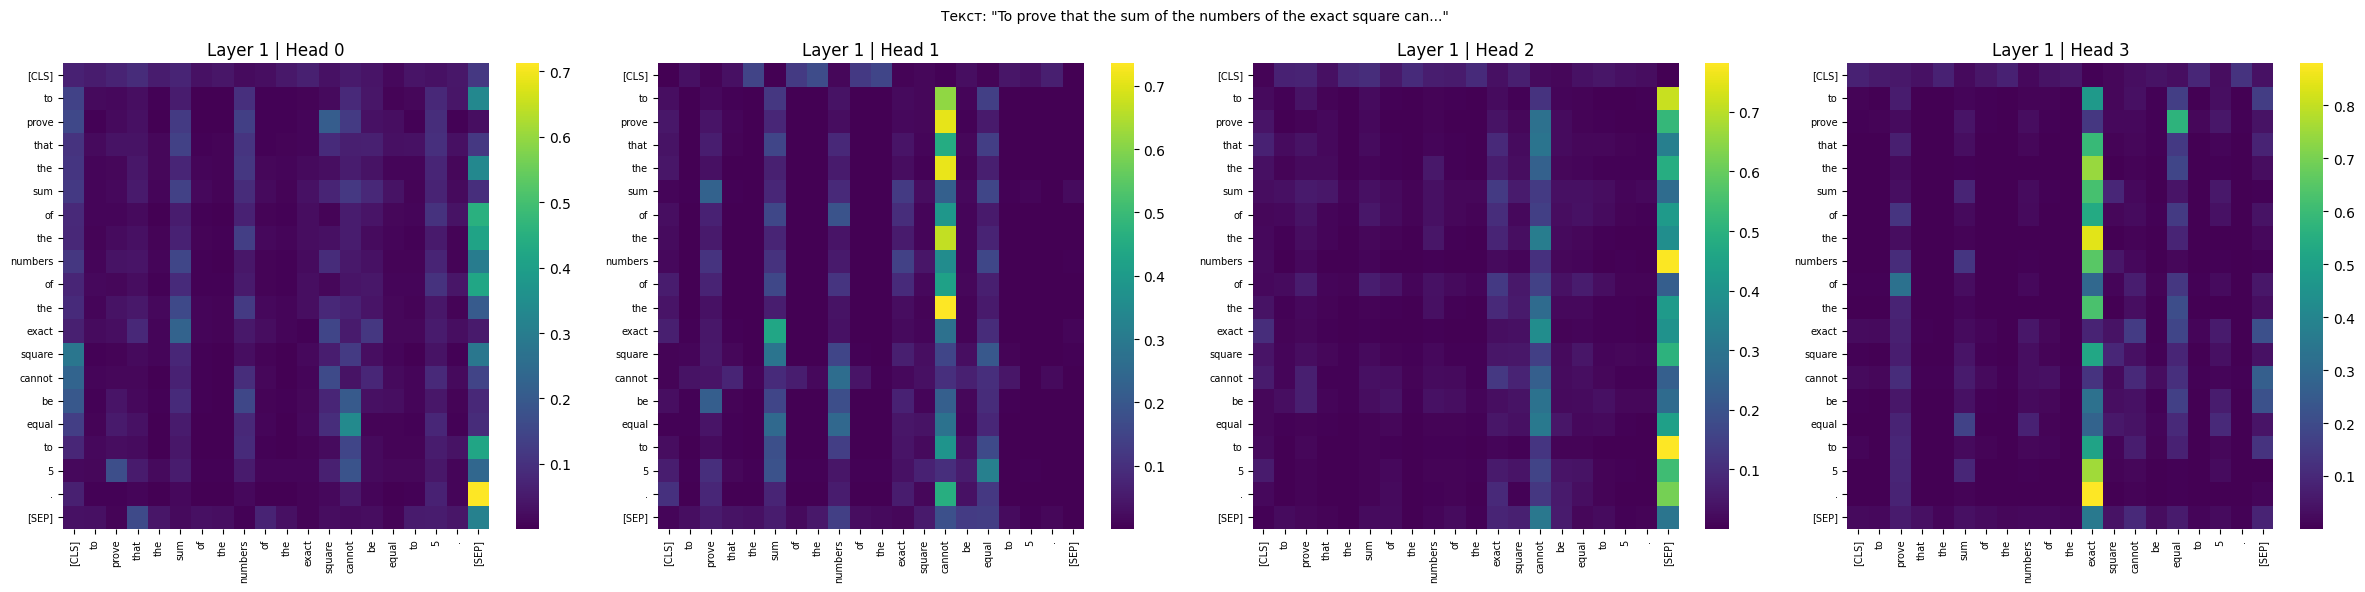


--- MathBert full (после дообучения) ---


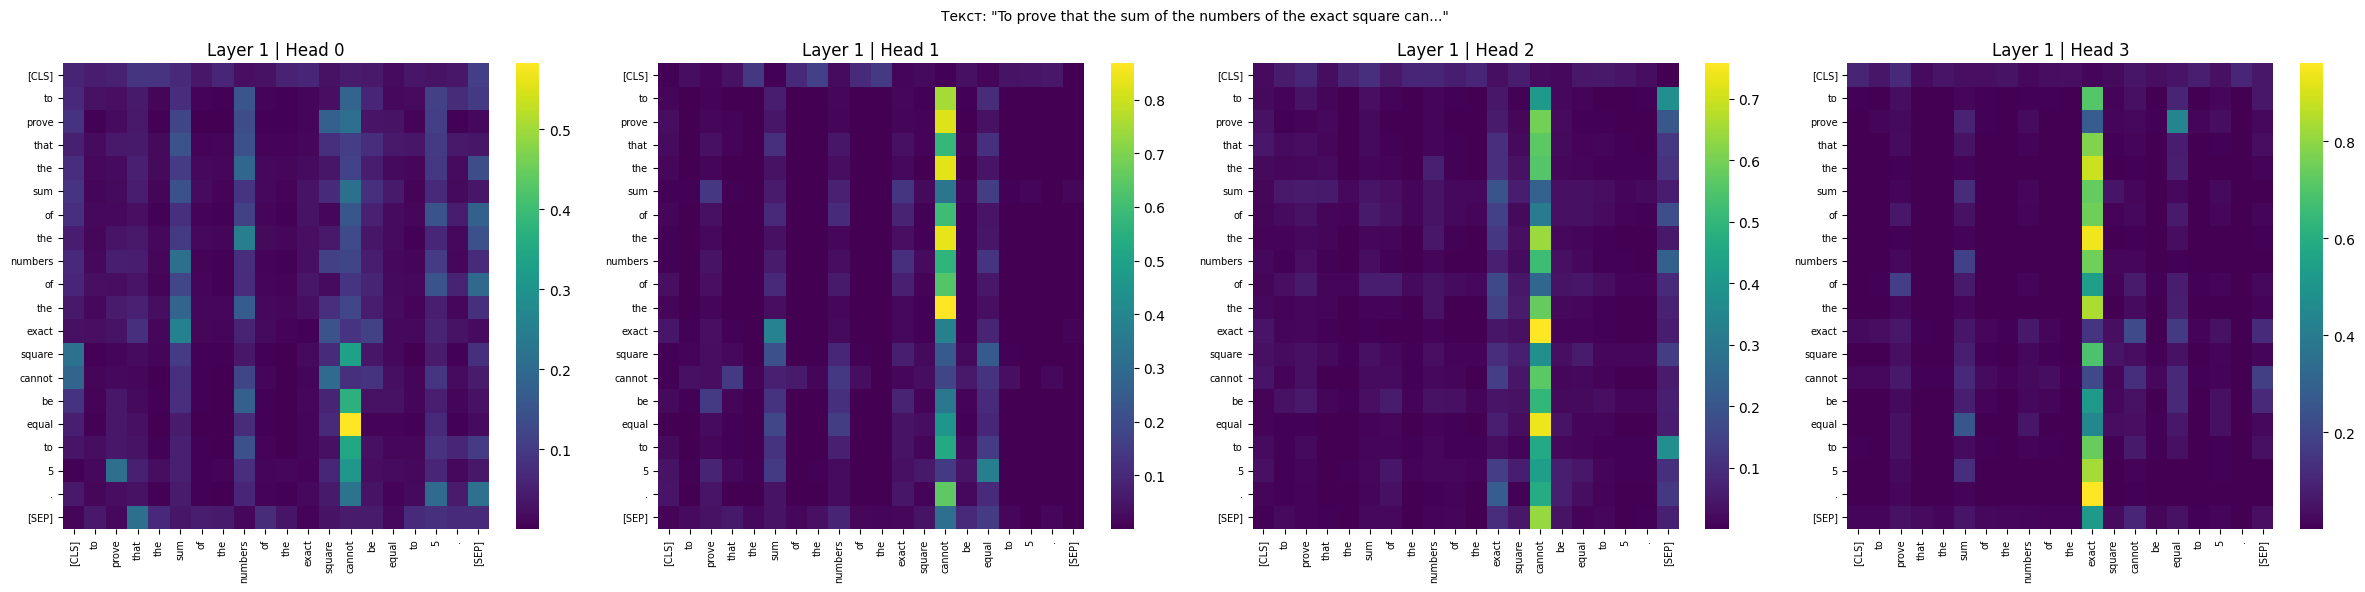


Текст 2: ( b) Will the statement of the previous challenge remain true if Petia and Wasa 

--- rubert-tiny2 frozen (после дообучения) ---


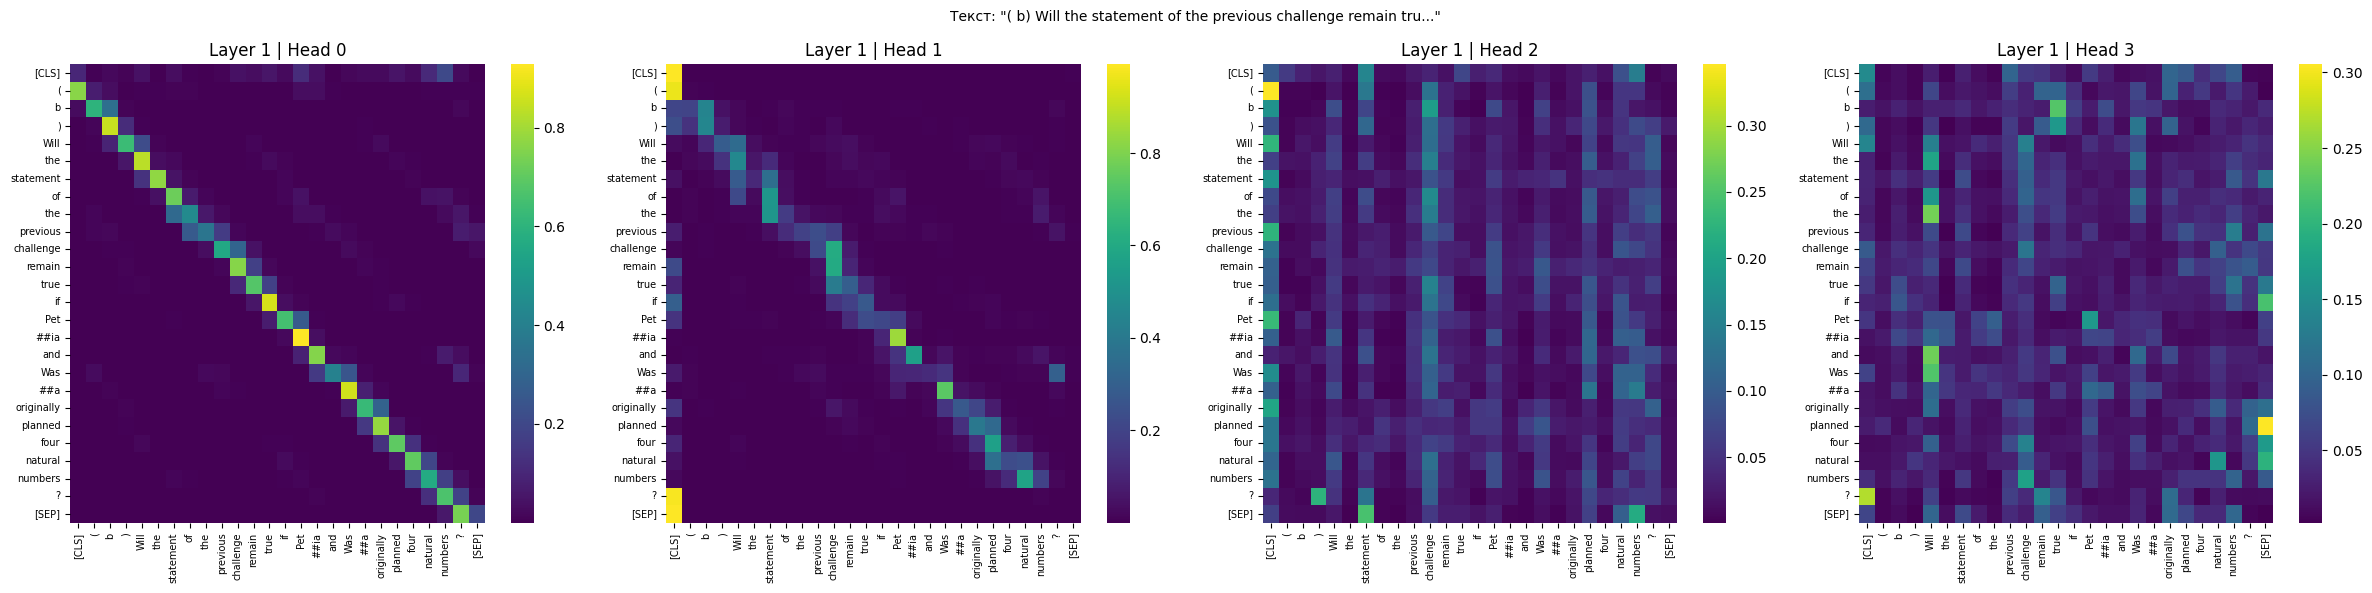


--- rubert-tiny2 full (после дообучения) ---


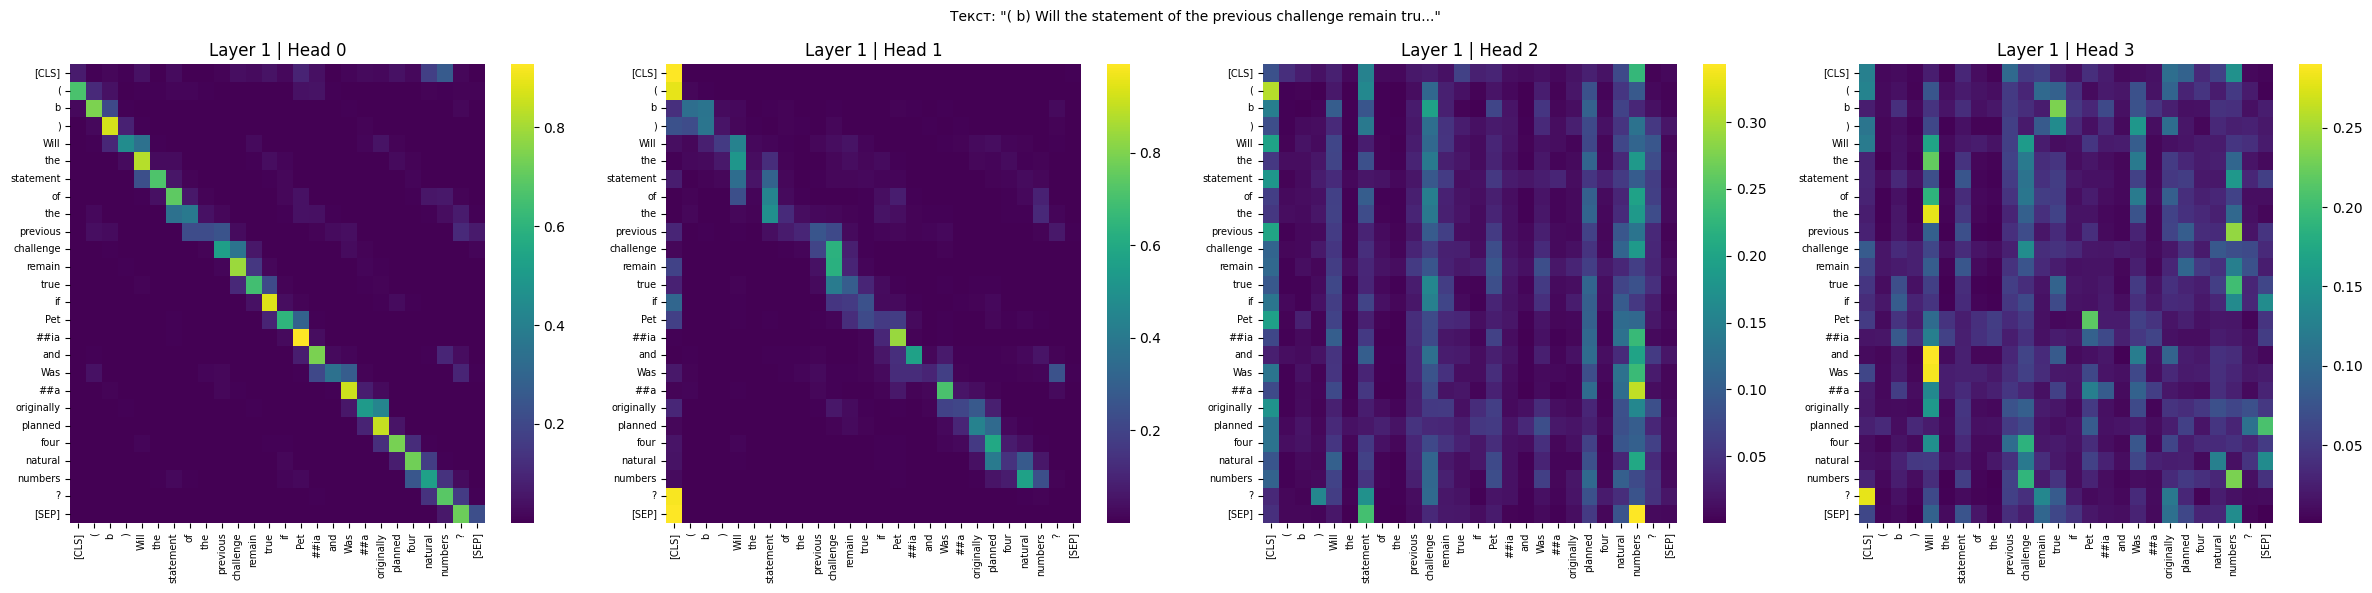


--- MathBert frozen (после дообучения) ---


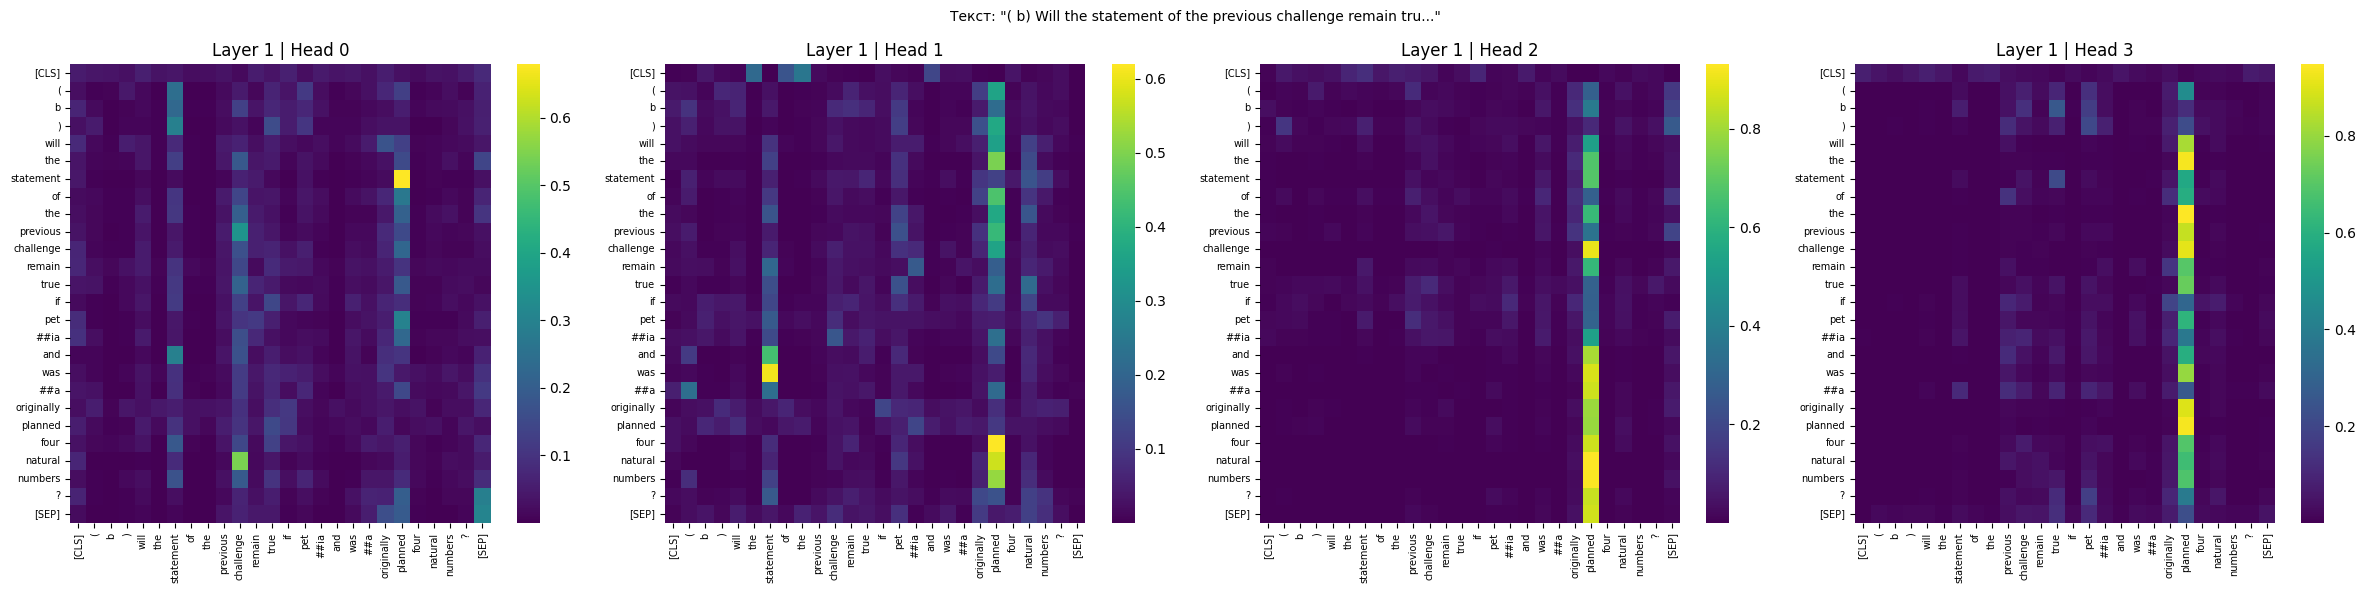


--- MathBert full (после дообучения) ---


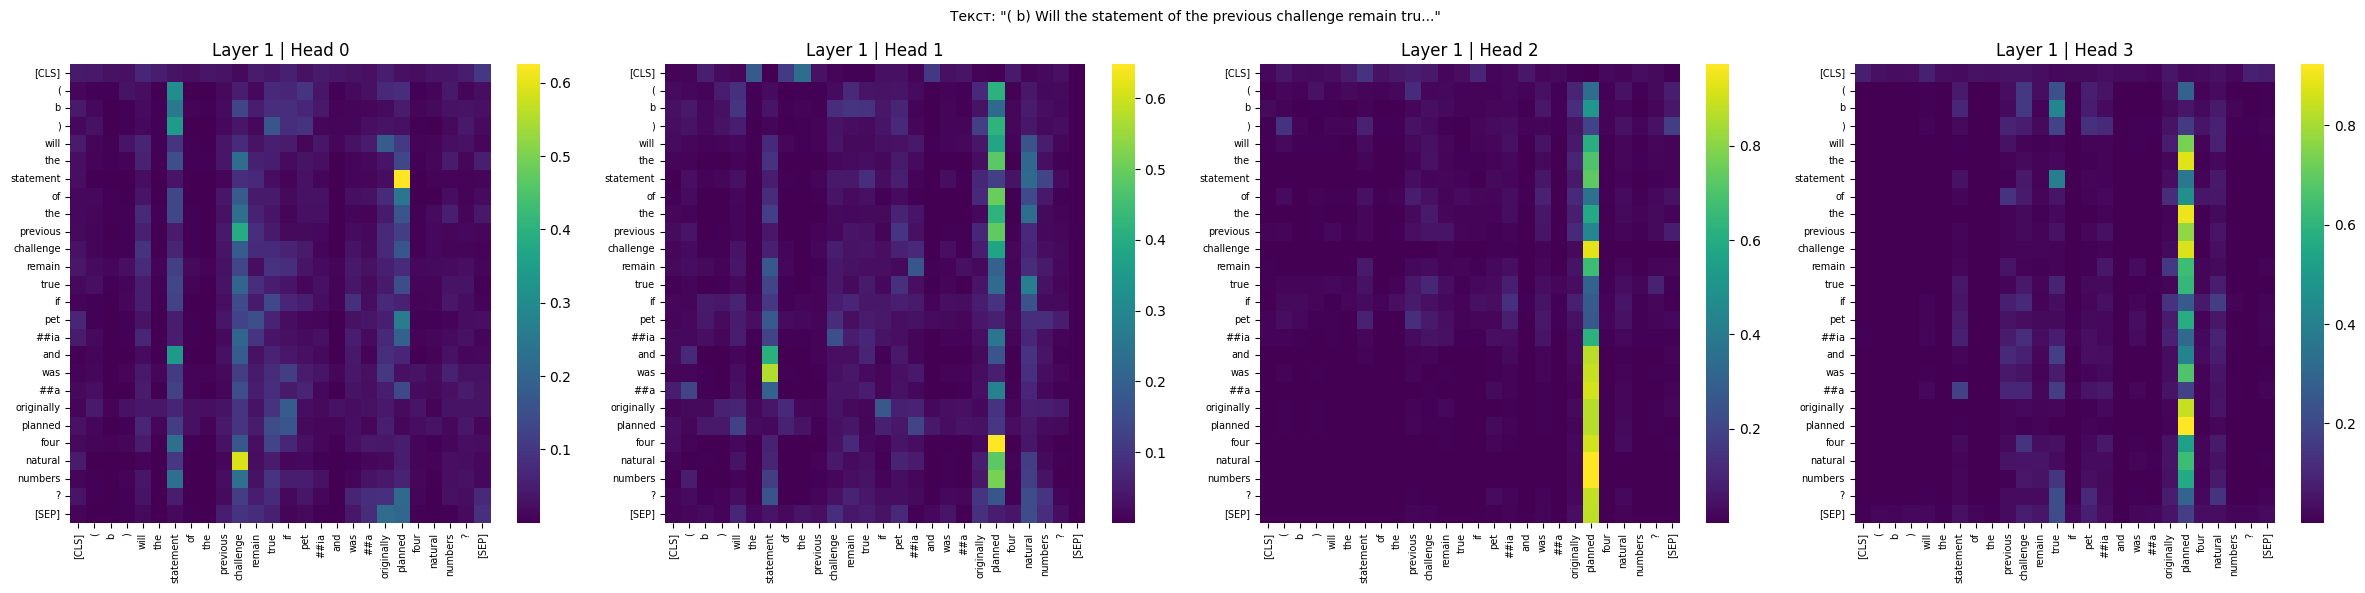


Текст 3: The quadratic three-member graph with the coefficients has two points with the c

--- rubert-tiny2 frozen (после дообучения) ---


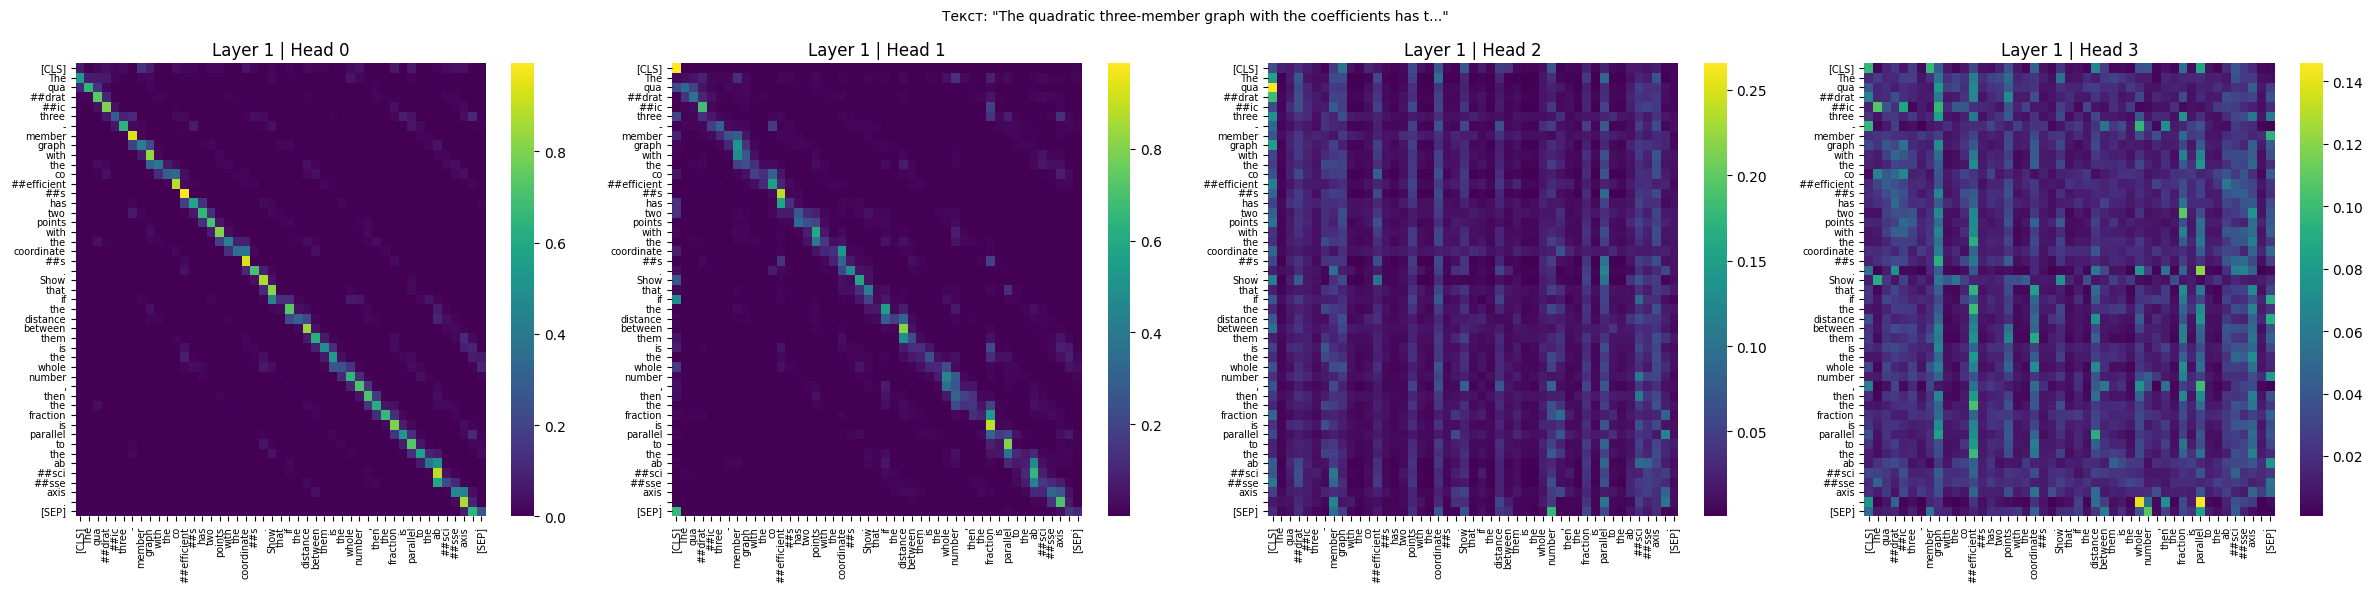


--- rubert-tiny2 full (после дообучения) ---


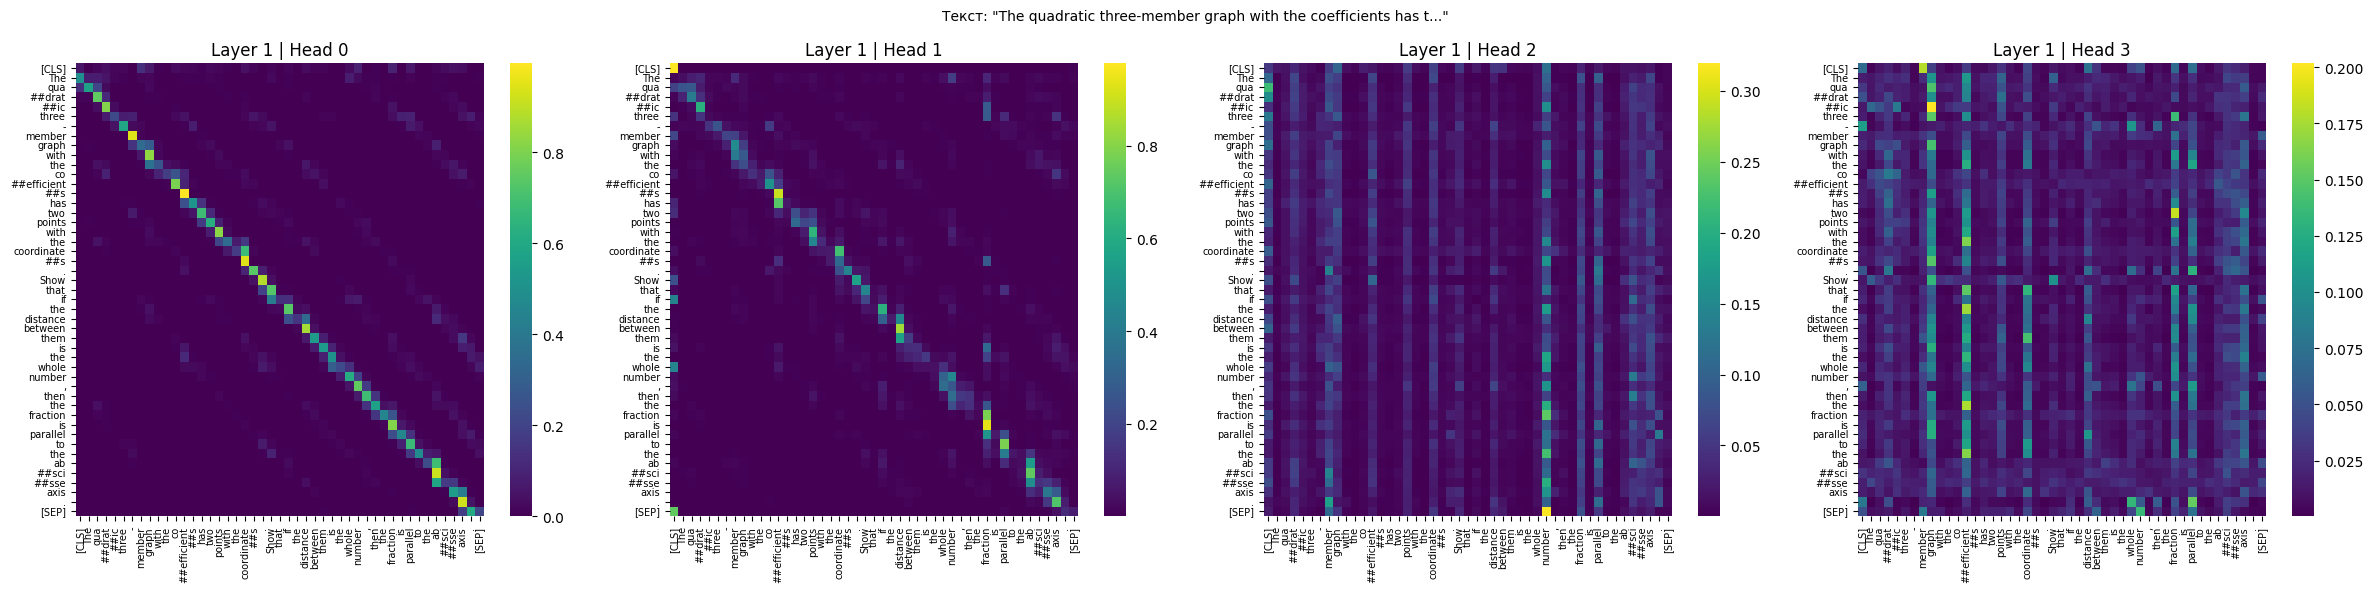


--- MathBert frozen (после дообучения) ---


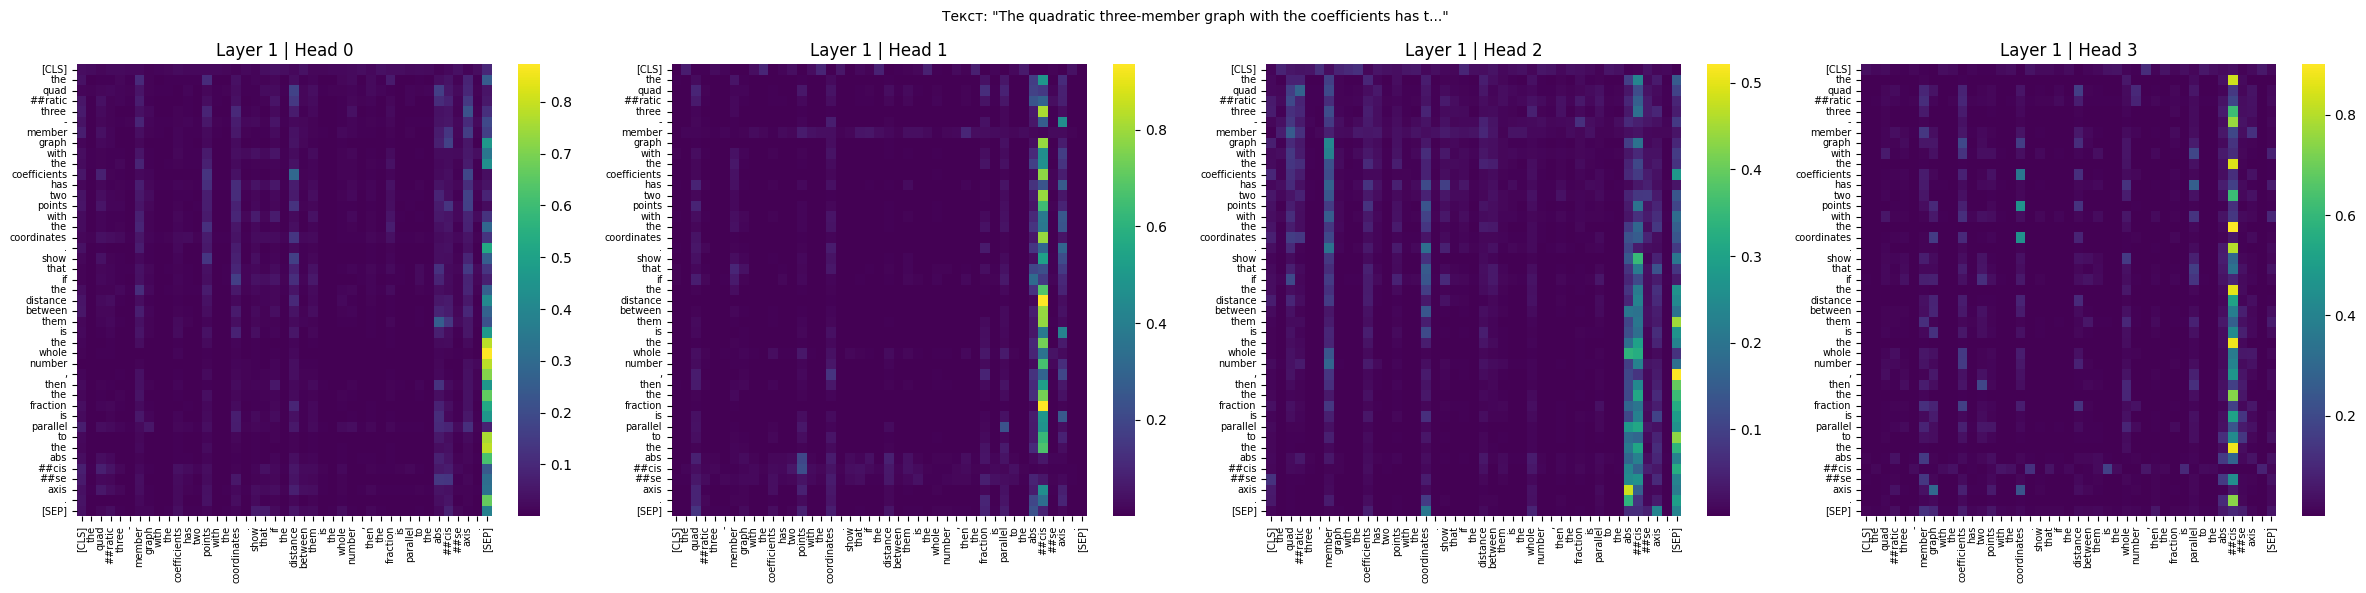


--- MathBert full (после дообучения) ---


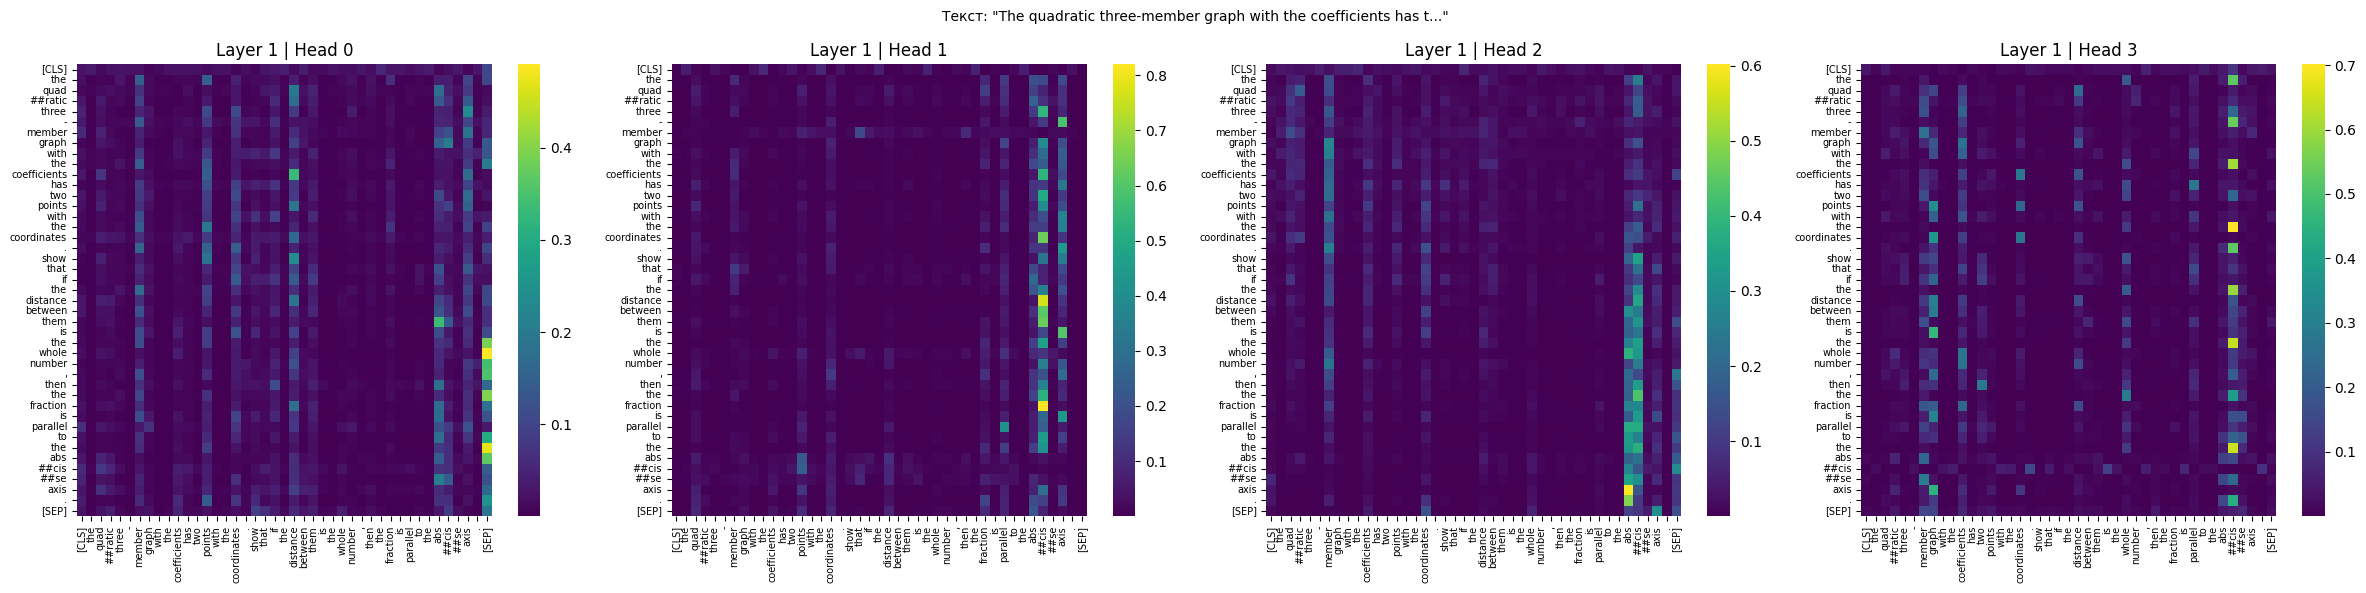

In [28]:
# модели ПОСЛЕ дообучения (уже обучены выше)
finetuned_models = {
    "rubert-tiny2 frozen":  rubert_tiny_finetuned_with_freezed_backbone,
    "rubert-tiny2 full":    rubert_tiny_full_finetuned,
    "MathBert frozen":      mathbert_frozen,
    "MathBert full":        mathbert_full,
}

for i, text in enumerate(sample_texts):
    print(f"\n{'='*60}")
    print(f"Текст {i+1}: {text[:80]}")

    for model_name, finetuned_model in finetuned_models.items():
        print(f"\n--- {model_name} (после дообучения) ---")
        n_heads = finetuned_model.backbone.config.num_attention_heads
        # показываем не более 4 голов для читаемости
        head_ids = list(range(min(4, n_heads)))
        draw_first_layer_attention_maps(
            attention_head_ids=head_ids,
            text=text,
            model=finetuned_model,
        )


# Вывод:
После дообучения карты внимания становятся более "осмысленными":
- При полном файнтюнинге (freeze_backbone=False) головы начинают явно акцентировать внимание на ключевых математических терминах (переменные, операторы, числа).
- При замороженном backbone карты первого слоя практически не меняются, т.к. веса backbone не обновлялись — меняется только классификационная голова.
- MathBert после дообучения показывает наиболее чёткие паттерны внимания на математической лексике, что объясняет его превосходство по метрикам.